In [5]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [6]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=9549610e18d9b9ab7c518607434074e805f5d60f1d0cf2a59d9473bb07af393f
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [8]:
def flip(n, p):
    choices = [1, 0]
    probs = [p, 1 - p]
    return np.random.choice(choices, n, p=probs)

In [9]:
# Seed the random number generator so we get the same results every time
np.random.seed(1)

In [10]:
flip(25, 0.9)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1])

In [11]:
from empiricaldist import Pmf

seq = flip(1000, 0.9)
pmf = Pmf.from_seq(seq)
pmf

,
0,0.101
1,0.899


In [12]:
def simulate_round(n, p):
    seq = flip(n, p)
    return seq.sum()

In [13]:
n = 25
p = 0.9
results_sim = [simulate_round(n, p) for i in range(1000)]

In [14]:
np.mean(results_sim), n * p

(np.float64(22.522), 22.5)

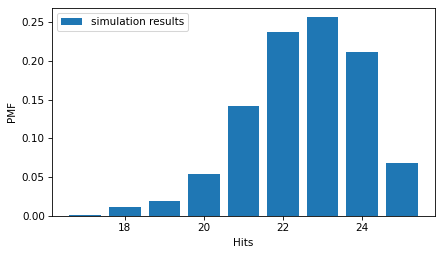

In [15]:
from empiricaldist import Pmf

pmf_sim = Pmf.from_seq(results_sim, name="simulation results")

pmf_sim.bar()
decorate(xlabel="Hits", ylabel="PMF")

In [16]:
from scipy.special import comb


def binomial_pmf(k, n, p):
    return comb(n, k) * (p**k) * ((1 - p) ** (n - k))

In [17]:
ks = np.arange(16, n + 1)
ps = binomial_pmf(ks, n, p)
pmf_binom = Pmf(ps, ks, name="binomial model")

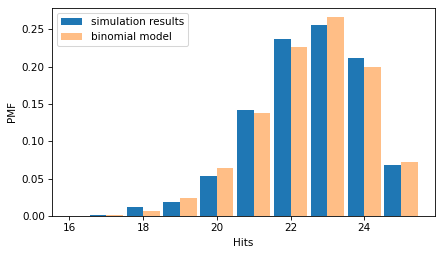

In [18]:
from thinkstats import two_bar_plots

two_bar_plots(pmf_sim, pmf_binom)
decorate(xlabel="Hits", ylabel="PMF")

In [19]:
filename = "Shooting_at_the_2020_Summer_Olympics_Mens_skeet"

In [20]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/" + filename)

Downloaded Shooting_at_the_2020_Summer_Olympics_Mens_skeet


In [21]:
tables = pd.read_html(filename)
table = tables[6]
table.head()

,Rank,Athlete,Country,1,2,3,4,5,Total[3],Shoot-off,Notes
0,1,Éric Delaunay,France,25,25,25,24,25,124,+6,"Q, OR"
1,2,Tammaro Cassandro,Italy,24,25,25,25,25,124,+5,"Q, OR"
2,3,Eetu Kallioinen,Finland,25,25,24,25,24,123,NaN,Q
3,4,Vincent Hancock,United States,25,25,25,25,22,122,+8,Q
4,5,Abdullah Al-Rashidi,Kuwait,25,25,24,25,23,122,+7,Q


In [22]:
columns = ["1", "2", "3", "4", "5"]
results = table[columns].values.flatten()

In [23]:
total_shots = 25 * len(results)
total_hits = results.sum()
n, total_shots, total_hits

(25, 3750, np.int64(3575))

In [24]:
p = total_hits / total_shots
p

np.float64(0.9533333333333334)

In [25]:
ps = binomial_pmf(ks, n, p)
pmf_binom = Pmf(ps, ks, name="binomial model")

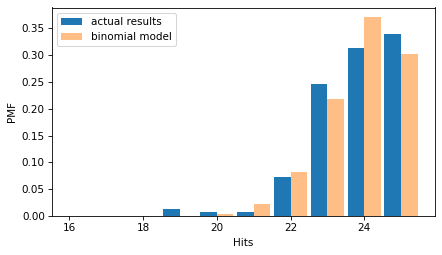

In [26]:
pmf_results = Pmf.from_seq(results, name="actual results")

two_bar_plots(pmf_results, pmf_binom)
decorate(xlabel="Hits", ylabel="PMF")

In [27]:
n = 3600
m = 6
p = m / 3600
p

0.0016666666666666668

In [28]:
def simulate_goals(n, p):
    return flip(n, p).sum()

In [29]:
goals = [simulate_goals(n, p) for i in range(1001)]
np.mean(goals)

np.float64(6.021978021978022)

In [30]:
from scipy.special import factorial


def poisson_pmf(k, lam):
    """Compute the Poisson PMF.

    k (int or array-like): The number of occurrences
    lam (float): The rate parameter (λ) of the Poisson distribution

    returns: float or ndarray
    """
    return (lam**k) * np.exp(-lam) / factorial(k)

In [31]:
lam = 6
ks = np.arange(20)
ps = poisson_pmf(ks, lam)
pmf_poisson = Pmf(ps, ks, name="Poisson model")

In [32]:
pmf_poisson.normalize()
pmf_poisson.mean()

np.float64(5.999925498375129)

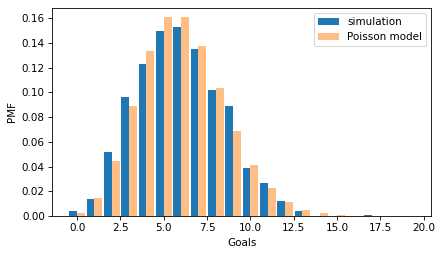

In [33]:
pmf_sim = Pmf.from_seq(goals, name="simulation")

two_bar_plots(pmf_sim, pmf_poisson)
decorate(xlabel="Goals", ylabel="PMF")

In [34]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/nhl_2023_2024.hdf")

Downloaded nhl_2023_2024.hdf


In [35]:
filename = "nhl_2023_2024.hdf"

with pd.HDFStore(filename, "r") as store:
    keys = store.keys()

len(keys), keys[0]

(1312, '/202310100PIT')

In [36]:
times = pd.read_hdf(filename, key=keys[0])
times

,0
0,424
1,1916
2,2137
3,3005
4,3329
5,3513


In [37]:
3600 - times[5]

np.int64(87)

In [38]:
goals = []

for key in keys:
    times = pd.read_hdf(filename, key=key)
    n = len(times)
    goals.append(n)

In [39]:
lam = np.mean(goals)
lam

np.float64(6.0182926829268295)

In [40]:
ps = poisson_pmf(ks, lam)
pmf_poisson = Pmf(ps, ks, name="Poisson model")

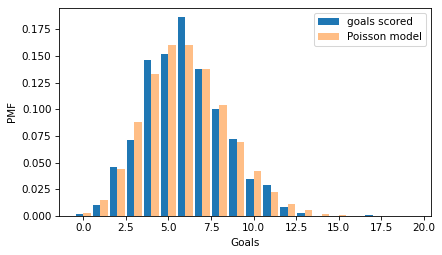

In [41]:
pmf_goals = Pmf.from_seq(goals, name="goals scored")

two_bar_plots(pmf_goals, pmf_poisson)
decorate(xlabel="Goals", ylabel="PMF")

In [42]:
n = 3600
m = 6
p = m / 3600
p

0.0016666666666666668

In [43]:
def simulate_first_goal(n, p):
    return flip(n, p).argmax()

In [44]:
np.random.seed(3)

In [45]:
first_goal_times = [simulate_first_goal(n, p) for i in range(1001)]
mean = np.mean(first_goal_times)
mean

np.float64(597.7902097902098)

In [46]:
def exponential_cdf(x, lam):
    """Compute the exponential CDF.

    x: float or sequence of floats
    lam: rate parameter

    returns: float or NumPy array of cumulative probability
    """
    return 1 - np.exp(-lam * x)

In [47]:
lam = 1 / mean
lam

np.float64(0.0016728276636563566)

In [48]:
from empiricaldist import Cdf

ts = np.linspace(0, 3600, 201)
ps = exponential_cdf(ts, lam)
cdf_expo = Cdf(ps, ts, name="exponential model")

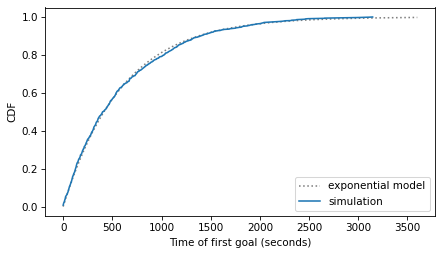

In [49]:
cdf_sim = Cdf.from_seq(first_goal_times, name="simulation")

cdf_expo.plot(ls=":", color="gray")
cdf_sim.plot()

decorate(xlabel="Time of first goal (seconds)", ylabel="CDF")

In [50]:
filename = "nhl_2023_2024.hdf"

with pd.HDFStore(filename, "r") as store:
    keys = store.keys()

In [51]:
firsts = []

for key in keys:
    times = pd.read_hdf(filename, key=key)
    if len(times) > 0:
        firsts.append(times[0])
    else:
        firsts.append(np.nan)

In [52]:
lam = 1 / np.nanmean(firsts)
lam

np.float64(0.0015121567467720825)

In [53]:
ps = exponential_cdf(ts, lam)
cdf_expo = Cdf(ps, ts, name="exponential model")

In [54]:
cdf_firsts = Cdf.from_seq(firsts, name="data", dropna=False)
cdf_firsts.tail()

,data
3286.0,0.996951
3581.0,0.997713
NaN,1.000000


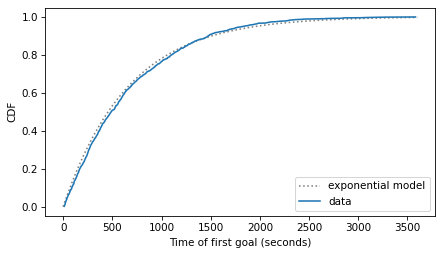

In [55]:
cdf_expo.plot(ls=":", color="gray")
cdf_firsts.plot()

decorate(xlabel="Time of first goal (seconds)", ylabel="CDF")

In [56]:
def simulate_growth(n):
    choices = [1, 2, 3]
    gains = np.random.choice(choices, n)
    return gains.sum()

In [57]:
sim_weights = [simulate_growth(100) for i in range(1001)]
m, s = np.mean(sim_weights), np.std(sim_weights)
m, s

(np.float64(199.37062937062936), np.float64(8.388630840376777))

In [58]:
from scipy.stats import norm


def make_normal_model(data):
    m, s = np.mean(data), np.std(data)
    low, high = m - 4 * s, m + 4 * s
    qs = np.linspace(low, high, 201)
    ps = norm.cdf(qs, m, s)
    return Cdf(ps, qs, name="normal model")

In [59]:
cdf_model = make_normal_model(sim_weights)

In [60]:
cdf_sim_weights = Cdf.from_seq(sim_weights, name="simulation")

In [61]:
def two_cdf_plots(cdf_model, cdf_data, xlabel="", **options):
    cdf_model.plot(ls=":", color="gray")
    cdf_data.plot(**options)
    decorate(xlabel=xlabel, ylabel="CDF")

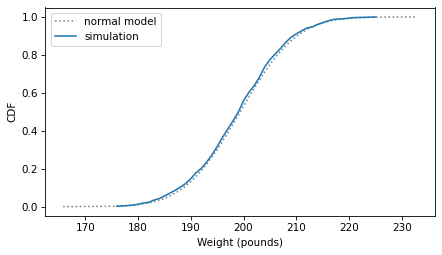

In [62]:
two_cdf_plots(cdf_model, cdf_sim_weights, xlabel="Weight (pounds)")

In [63]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded nsfg.py
Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [64]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [65]:
import nsfg

preg = nsfg.read_fem_preg()
birth_weights = preg["totalwgt_lb"].dropna()

In [66]:
m, s = np.mean(birth_weights), np.std(birth_weights)
m, s

(np.float64(7.265628457623368), 1.4082155338406195)

In [67]:
from scipy.stats import trimboth

trimmed = trimboth(birth_weights, 0.01)
m, s = np.mean(trimmed), np.std(trimmed)
m, s

(np.float64(7.280883100022579), np.float64(1.2430657948614345))

In [68]:
cdf_model = make_normal_model(trimmed)

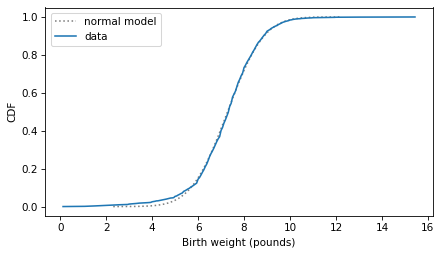

In [69]:
cdf_birth_weight = Cdf.from_seq(birth_weights, name='data')

two_cdf_plots(cdf_model, cdf_birth_weight, xlabel="Birth weight (pounds)")

In [70]:
def simulate_proportionate_growth(n):
    choices = [1.03, 1.05, 1.07]
    gains = np.random.choice(choices, n)
    return gains.prod()

In [71]:
sim_weights = [simulate_proportionate_growth(100) for i in range(1001)]
np.mean(sim_weights), np.std(sim_weights)

(np.float64(130.80183363824722), np.float64(20.956047434921466))

In [72]:
log_sim_weights = np.log10(sim_weights)
m, s = np.mean(log_sim_weights), np.std(log_sim_weights)
m, s

(np.float64(2.1111299372609933), np.float64(0.06898607064749827))

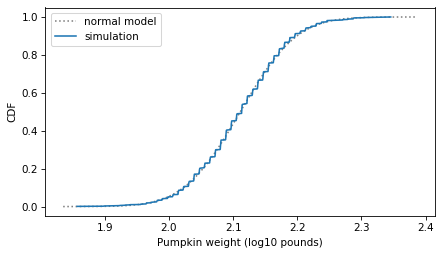

In [73]:
cdf_model = make_normal_model(log_sim_weights)
cdf_log_sim_weights = Cdf.from_seq(log_sim_weights, name="simulation")

two_cdf_plots(
    cdf_model, cdf_log_sim_weights, xlabel="Pumpkin weight (log10 pounds)"
)

In [74]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/CDBRFS08.ASC.gz")

Downloaded CDBRFS08.ASC.gz


In [75]:
from thinkstats import read_brfss

brfss = read_brfss()

In [76]:
adult_weights = brfss["wtkg2"].dropna()
m, s = np.mean(adult_weights), np.std(adult_weights)
m, s

(np.float64(78.9924529968581), 19.54613238740293)

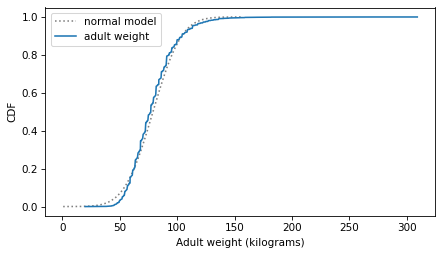

In [77]:
cdf_model = make_normal_model(adult_weights)
cdf_adult_weights = Cdf.from_seq(adult_weights, name="adult weight")

two_cdf_plots(cdf_model, cdf_adult_weights, xlabel="Adult weight (kilograms)")

In [78]:
log_adult_weights = np.log10(adult_weights)
cdf_model = make_normal_model(log_adult_weights)

cdf_log_adult_weights = Cdf.from_seq(log_adult_weights, name="log adult weight")

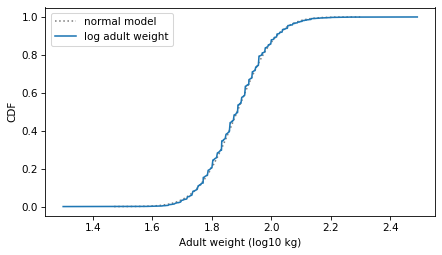

In [79]:
two_cdf_plots(cdf_model, cdf_log_adult_weights, xlabel="Adult weight (log10 kg)")

## Exercises

In [80]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dat.gz")

Downloaded 2002FemResp.dct
Downloaded 2002FemResp.dat.gz


In [81]:
from nsfg import read_fem_resp

resp = read_fem_resp()

In [82]:
older = resp.query("age >= 25")
num_family = older["numfmhh"]

Mean: 2.2185185185185183


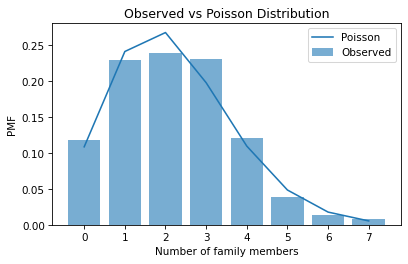

In [83]:
# Exercise 5.1

from empiricaldist import Pmf, Cdf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, expon, norm

from nsfg import read_fem_resp

# Read respondent data
resp = read_fem_resp()

# Select respondents age 25+
older = resp.query("age_r >= 25")

# Select household family members column
numfmhh = older['numfmhh'].dropna()

# PMF of observed data
pmf_numfmhh = Pmf.from_seq(numfmhh)

# Mean of observed data
mu = numfmhh.mean()

print("Mean:", mu)

# Poisson model

xs = np.arange(0, numfmhh.max() + 1)

ps = poisson.pmf(xs, mu)

pmf_poisson = Pmf(ps, xs)

# Plot comparison

pmf_numfmhh.bar(label='Observed', alpha=0.6)
pmf_poisson.plot(label='Poisson')

plt.xlabel("Number of family members")
plt.ylabel("PMF")
plt.title("Observed vs Poisson Distribution")
plt.legend()

plt.show()

In [84]:
filename = "nhl_2023_2024.hdf"

with pd.HDFStore(filename, "r") as store:
    keys = store.keys()

In [85]:
intervals = []

for key in keys:
    times = pd.read_hdf(filename, key=key)
    if len(times) > 1:
        intervals.extend(times.diff().dropna())

In [95]:
# Exercise 5.2

import numpy as np
import matplotlib.pyplot as plt

from empiricaldist import Cdf

# Convert intervals to numpy array
intervals = np.array(intervals)

# Mean inter-goal time
mean_interval = intervals.mean()

print("Mean interval =", mean_interval)

Mean interval = 489.9951419462578


In [96]:
# Function for exponential CDF

def exponential_cdf(x, lam):

    return 1 - np.exp(-lam * x)

In [97]:
# Create observed CDF
cdf_intervals = Cdf.from_seq(intervals)

# Exponential distribution parameter
lam = 1 / mean_interval

# x-values
xs = np.linspace(0, intervals.max(), 200)

# Model CDF
ys = exponential_cdf(xs, lam)

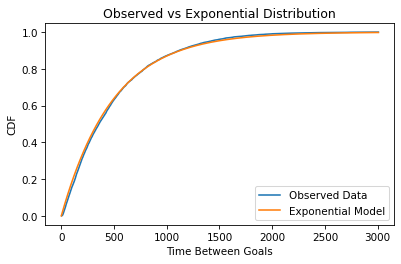

In [98]:
# Plot comparison

cdf_intervals.plot(label="Observed Data")

plt.plot(xs, ys, label="Exponential Model")

plt.xlabel("Time Between Goals")
plt.ylabel("CDF")
plt.title("Observed vs Exponential Distribution")

plt.legend()

plt.show()

In [99]:
# Optional: compare first few values

print("First 10 intervals:")
print(intervals[:10])

First 10 intervals:
[1492.  221.  868.  324.  184. 1587.  236.  134.   42.  341.]


In [86]:
adult_heights = brfss["htm3"].dropna()
m, s = np.mean(adult_heights), np.std(adult_heights)
m, s

(np.float64(168.82518961012298), 10.352640156457166)

In [109]:
# Exercise 5.3

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from empiricaldist import Cdf
from scipy.stats import norm

In [110]:
# Download BRFSS dataset directly

!wget -nc https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/data/CDBRFS08.ASC.gz

File ‘CDBRFS08.ASC.gz’ already there; not retrieving.



In [111]:
# Read fixed-width BRFSS data

colspecs = [(123, 127)]   # Height column location
names = ['height']

brfss = pd.read_fwf(
    'CDBRFS08.ASC.gz',
    colspecs=colspecs,
    names=names,
    compression='gzip'
)

print(brfss.head())

   height
0    5020
1    5040
2     505
3    5070
4    6010


In [112]:
# Clean heights

heights = brfss['height']

# Remove invalid values
heights = heights.replace([9999], np.nan)

# Drop NaN
heights = heights.dropna()

# Keep realistic heights
heights = heights[(heights > 100) & (heights < 250)]

# Convert to numpy array
heights = np.array(heights)

print("Number of heights =", len(heights))

Number of heights = 70


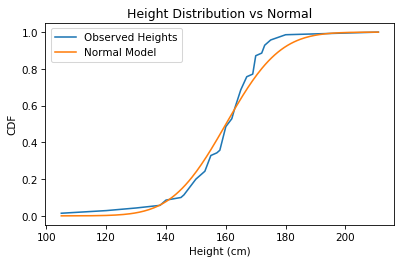

In [113]:
# -----------------------------
# Heights vs Normal Distribution
# -----------------------------

cdf_heights = Cdf.from_seq(heights)

mu = heights.mean()
sigma = heights.std()

xs = np.linspace(heights.min(), heights.max(), 200)

normal_model = norm.cdf(xs, loc=mu, scale=sigma)

# Plot
cdf_heights.plot(label='Observed Heights')

plt.plot(xs, normal_model, label='Normal Model')

plt.xlabel("Height (cm)")
plt.ylabel("CDF")
plt.title("Height Distribution vs Normal")

plt.legend()

plt.show()

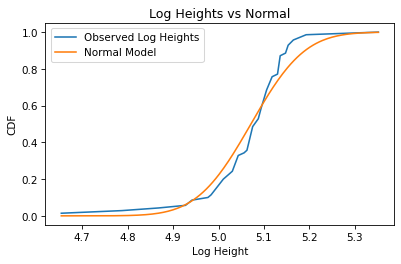

In [114]:
# -----------------------------
# Log Heights vs Normal
# -----------------------------

log_heights = np.log(heights)

cdf_logs = Cdf.from_seq(log_heights)

mu_log = log_heights.mean()
sigma_log = log_heights.std()

xs_log = np.linspace(log_heights.min(), log_heights.max(), 200)

log_model = norm.cdf(xs_log, loc=mu_log, scale=sigma_log)

# Plot
cdf_logs.plot(label='Observed Log Heights')

plt.plot(xs_log, log_model, label='Normal Model')

plt.xlabel("Log Height")
plt.ylabel("CDF")
plt.title("Log Heights vs Normal")

plt.legend()

plt.show()